## MODEL DEVELOPMENT

In [1]:
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
import sys

BASE          = Path("/share/home/e2406751/Superresolution-TIR")
PATCHES_DIR   = BASE / "data/processed/patches"
STATS_PATH    = PATCHES_DIR / "stats.json"
METADATA_PATH = PATCHES_DIR / "metadata.json"
sys.path.insert(0, str(BASE))

with open(STATS_PATH) as f:
    stats_data = json.load(f)

HR_MEAN    = stats_data["hr"]["mean"]
HR_STD     = stats_data["hr"]["std"]
LR_MEAN    = stats_data["lr"]["mean"]
LR_STD     = stats_data["lr"]["std"]
DATA_RANGE = stats_data["hr_data_range"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from scripts.utils.dataset import SRDataset

val_ds = SRDataset(
    split="val",
    patches_dir=PATCHES_DIR,
    stats_path=STATS_PATH,
    use_aux=True,
    use_water_mask=True,
    aux_dir=str(PATCHES_DIR / "val" / "AUX"),
    repeat_channels=False,
    transform=None,
)
print(f"val set size: {len(val_ds)} samples")

val set size: 36 samples


In [3]:
from scripts.models.swinir import SwinIRModule

sample_0     = val_ds[0]
in_aux_chans = sample_0["aux"].shape[0]

model = SwinIRModule.load_from_checkpoint(
    checkpoint_path=str(BASE / "checkpoints/dev_v2/swinir/best-epoch=80-val_full_psnr=18.2714.ckpt"),
    adaptation_strategy="projection",
    in_aux_chans=in_aux_chans,
    hr_mean=HR_MEAN,
    hr_std=HR_STD,
    data_range=DATA_RANGE,
)
model = model.to(device).eval()

# checkpoints
# best-epoch=80-val_full_psnr=18.2714.ckpt  #projection
# best-epoch=88-val_full_psnr=18.6415.ckpt   #direct 
# best-epoch=62-val_full_psnr=18.5332.ckpt   #direct - partial preserve init
# best-epoch=63-val_full_psnr=18.5204.ckpt   #direct - gaussian init
# best-epoch=46-val_full_psnr=18.1197.ckpt   #direct - xavier init
# best-epoch=47-val_full_psnr=18.2124.ckpt   #direct - he init

/share/home/e2406751/.conda/envs/sisr/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/share/home/e2406751/.conda/envs/s

[INFO] Loaded 550 / 550 weights

================ MODEL SETUP ================
Strategy       : projection
Freeze backbone : False
Freeze mode     : none



In [4]:
np.random.seed(42)
N_SAMPLES   = 5
vis_indices = np.random.choice(len(val_ds), N_SAMPLES, replace=False)
vis_samples = [val_ds[i] for i in vis_indices]
print(f"\nSelected tiles for viz: {[s['fname'] for s in vis_samples]}")


Selected tiles for viz: ['PDR_2023_b2_r2816_c1024.npy', 'DZM_2014_b2_r2816_c0.npy', 'PDR_2014_b1_r1024_c256.npy', 'PDR_2023_b2_r2048_c512.npy', 'DZM_2019_b1_r1280_c0.npy']


In [5]:
def prep_sample(sample):
    hr_mask = sample["hr_mask"].squeeze().numpy()
    lr_64   = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256  = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    lr_np   = np.where(hr_mask > 0.5, lr_256, np.nan)
    hr_np   = sample["hr"][0].numpy() * HR_STD + HR_MEAN
    hr_np   = np.where(hr_mask > 0.5, hr_np, np.nan)
    valid   = hr_np[hr_mask > 0.5]
    vmin    = np.nanpercentile(valid, 2)
    vmax    = np.nanpercentile(valid, 98)
    return lr_np, hr_np, hr_mask, vmin, vmax


def run_inference(sample):
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}
    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)
    with torch.no_grad():
        sr = model(batch)
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()
    return sr_celsius

### projected aux

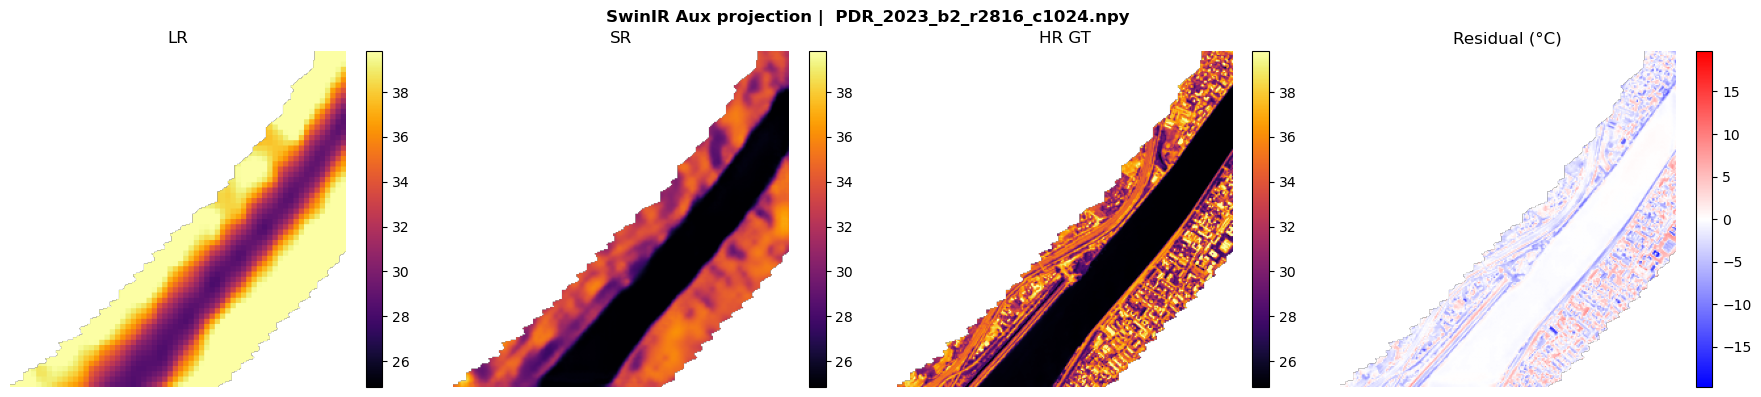

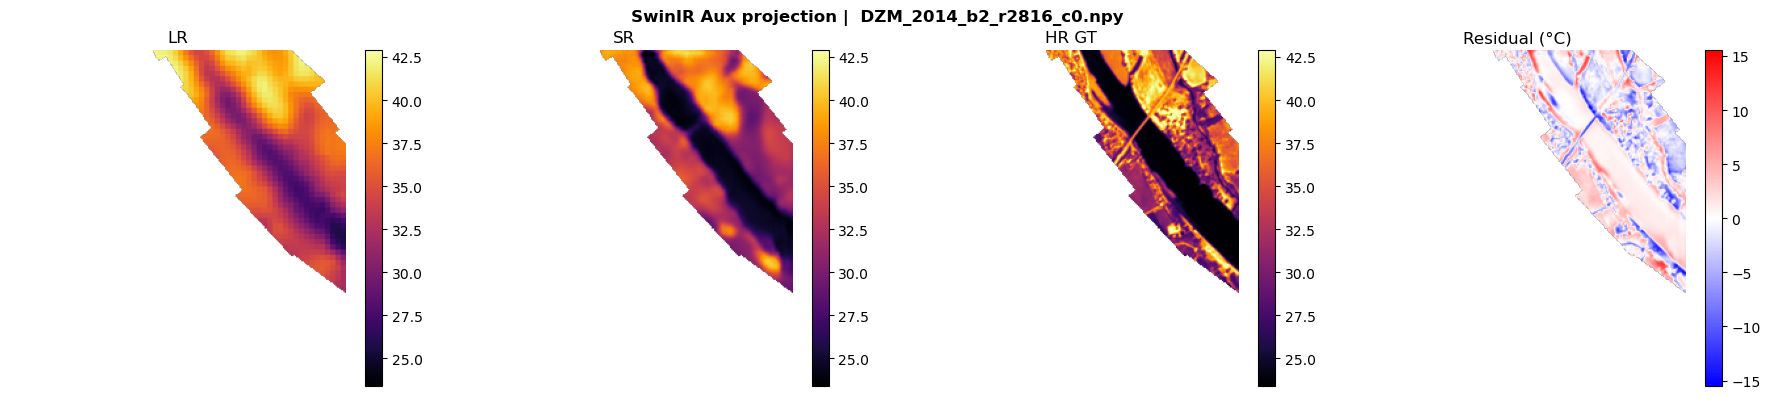

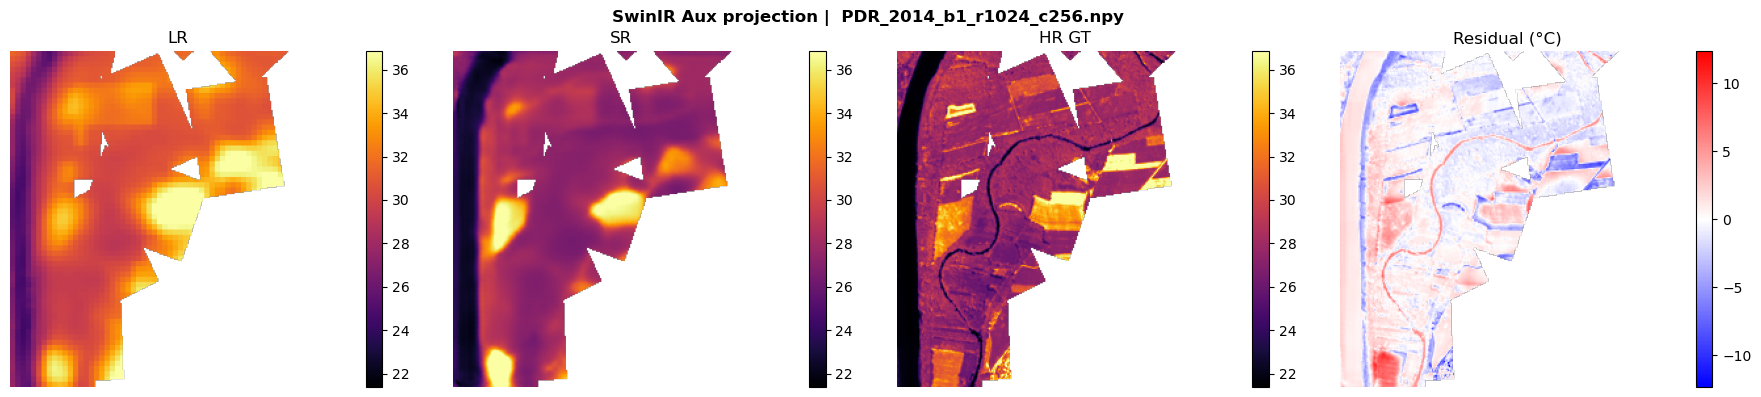

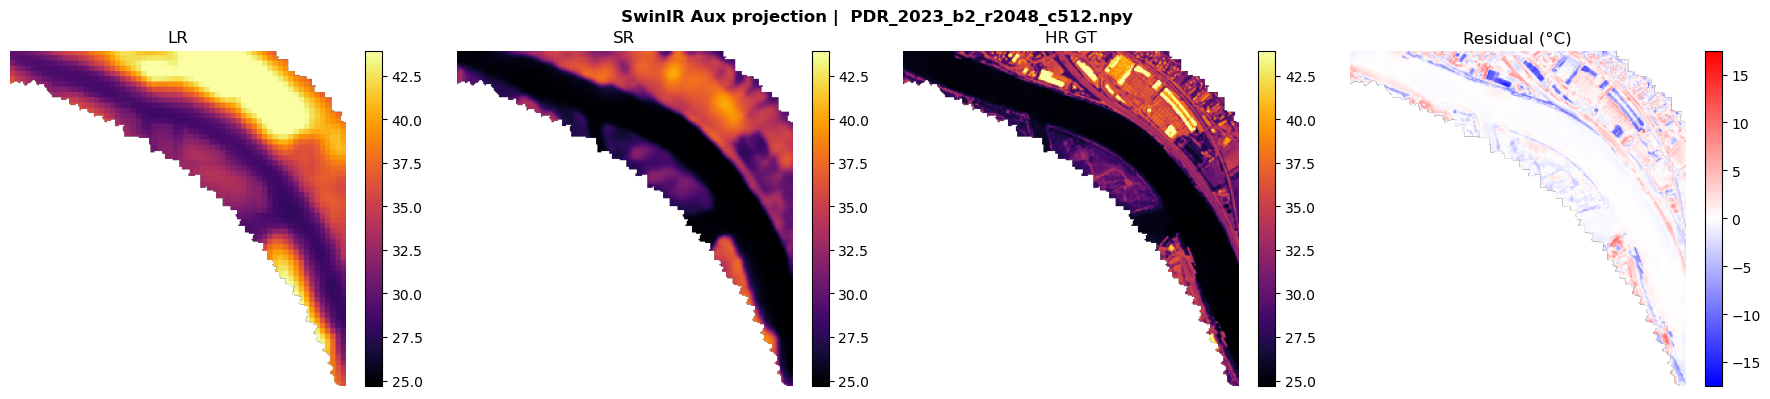

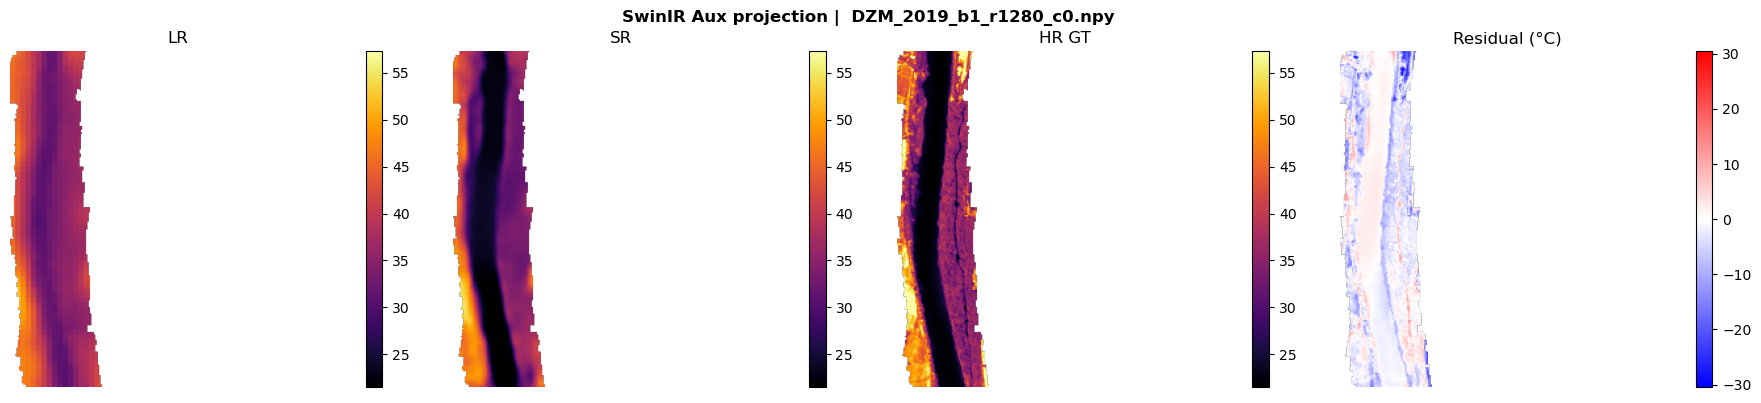

In [13]:
for sample in vis_samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux projection |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual (°C)"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()


Running inference on full val set (36 samples)...


  36/36 done
Total valid pixels: 763,366


/tmp/ipykernel_4005073/3007266701.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scat.legend(fontsize=10, loc="upper left")


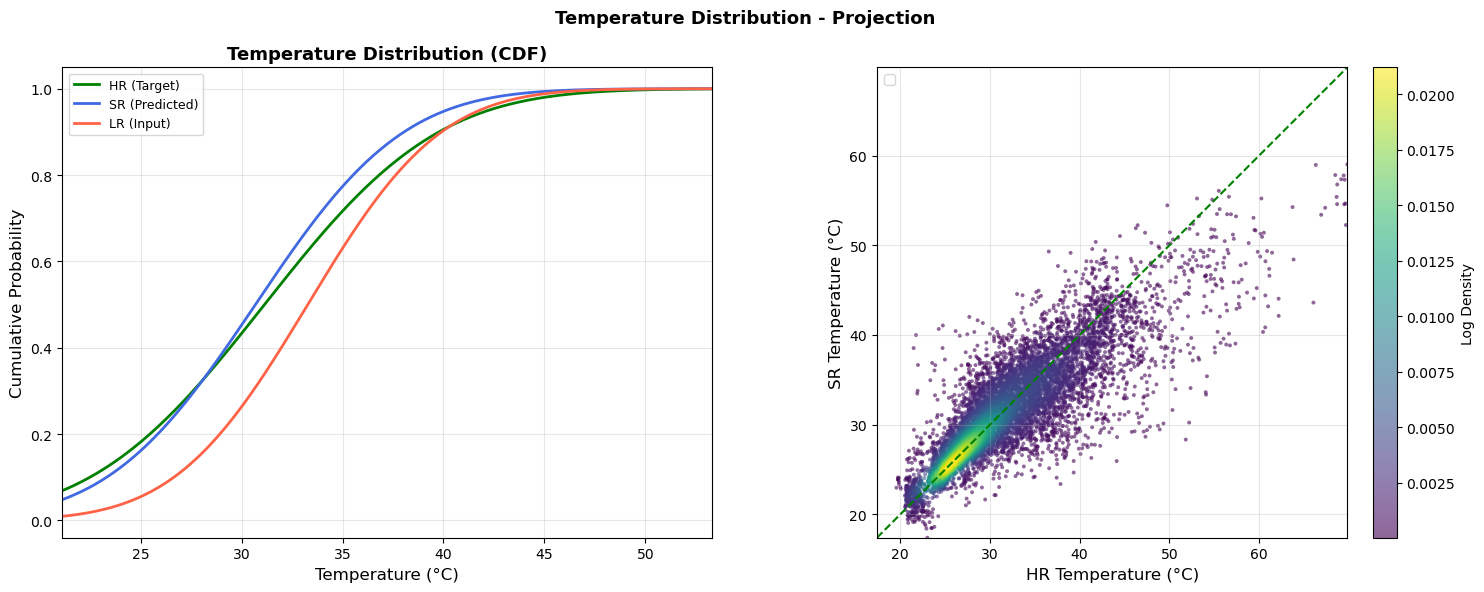

In [7]:
print(f"\nRunning inference on full val set ({len(val_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(val_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()  # ← add this

    # valid_mask = (hr_mask > 0.5) & (water_mask > 0.5)   # ← both conditions
    valid_mask = hr_mask > 0.5 

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])

    if (i + 1) % 50 == 0 or (i + 1) == len(val_ds):
        print(f"  {i + 1}/{len(val_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

vmin = np.percentile(hr_valid, 1)
vmax = np.percentile(hr_valid, 99)

palette = {"HR": "green",  "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid,     "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Temperature Distribution - Projection",
             fontsize=13, fontweight="bold")

# CDF
ax_cdf = axes[0]
x      = np.linspace(vmin, vmax, 500) 

for key, vals in data.items():
    mu, std = stats.norm.fit(vals)
    ax_cdf.plot(
        x, stats.norm.cdf(x, mu, std),
        color=palette[key], lw=2,
        # label=f"{labels[key]} (μ={mu:.1f}°C, σ={std:.1f}°C)"
        label = f"{labels[key]}"
    )


ax_cdf.set_xlim(vmin, vmax)
ax_cdf.set_xlabel("Temperature (°C)", fontsize=12)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=12)
ax_cdf.set_title("Temperature Distribution (CDF)", fontsize=13, fontweight="bold")
ax_cdf.legend(fontsize=9, loc="upper left")
ax_cdf.grid(True, alpha=0.3)


# Scatter (subsample 10k points for speed)
ax_scat    = axes[1]
n_pts      = min(len(hr_valid), 10_000)
idx_sample = np.random.choice(len(hr_valid), n_pts, replace=False)
hr_s       = hr_valid[idx_sample]
sr_s       = sr_valid[idx_sample]

t_min = min(hr_s.min(), sr_s.min())
t_max = max(hr_s.max(), sr_s.max())

density     = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
log_density = np.log1p(density)
order       = log_density.argsort()

sc = ax_scat.scatter(
    hr_s[order], sr_s[order],
    c=log_density[order], cmap="viridis",
    s=8, alpha=0.6, linewidths=0
)
fig.colorbar(sc, ax=ax_scat, label="Log Density", fraction=0.046, pad=0.04)

ax_scat.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5)
ax_scat.set_xlim(t_min, t_max)
ax_scat.set_ylim(t_min, t_max)
ax_scat.set_aspect("equal")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=12)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=12)
ax_scat.legend(fontsize=10, loc="upper left")
ax_scat.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### modified first layer

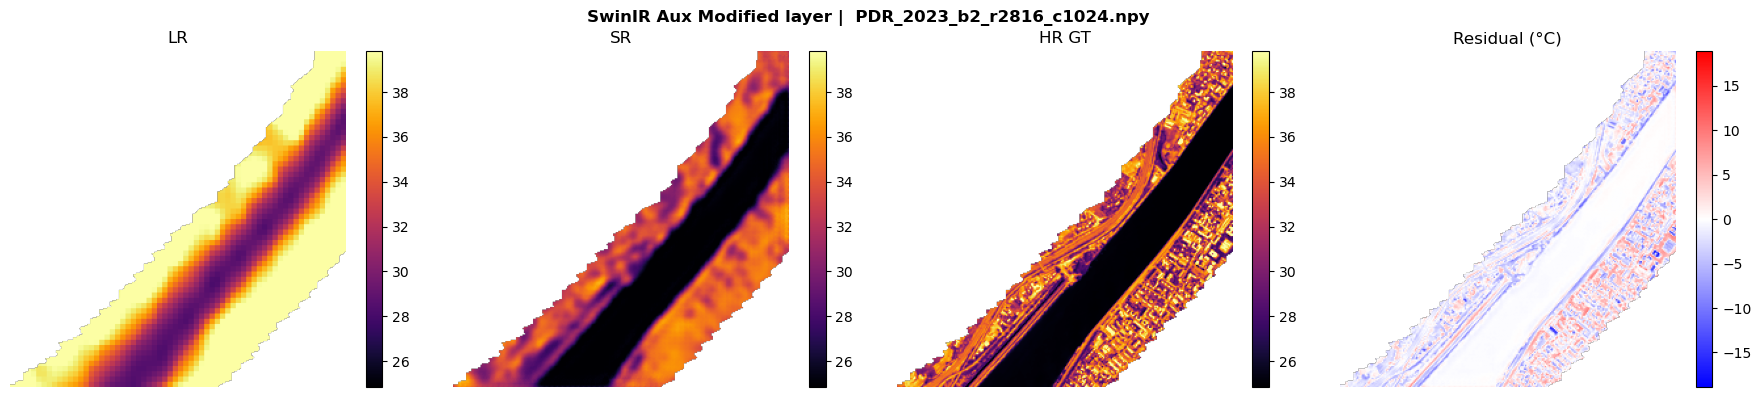

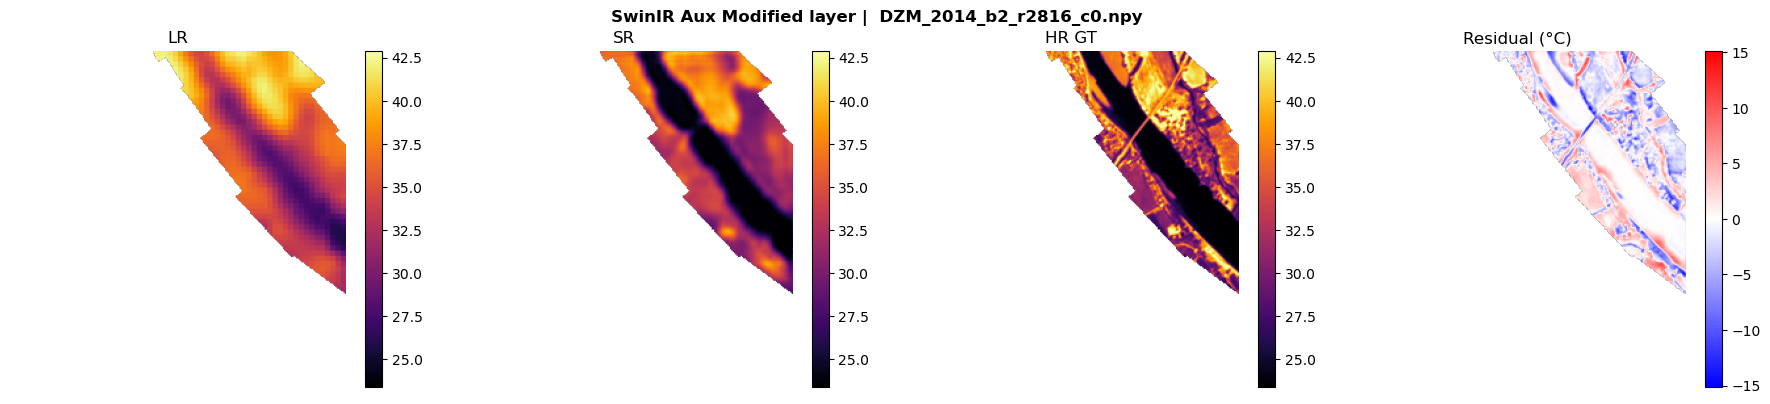

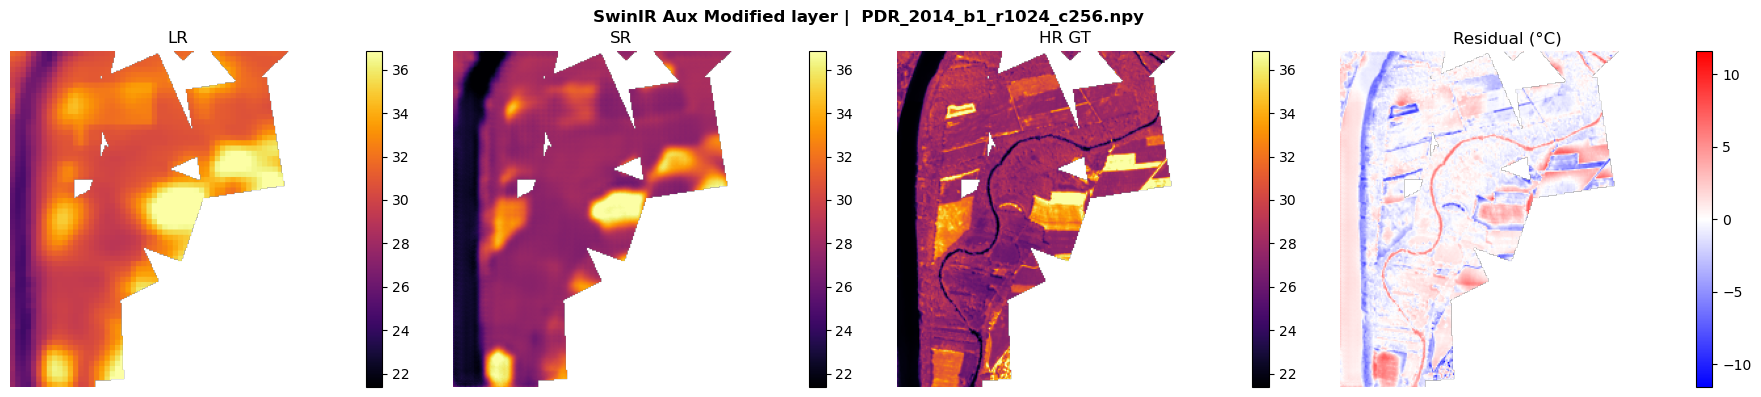

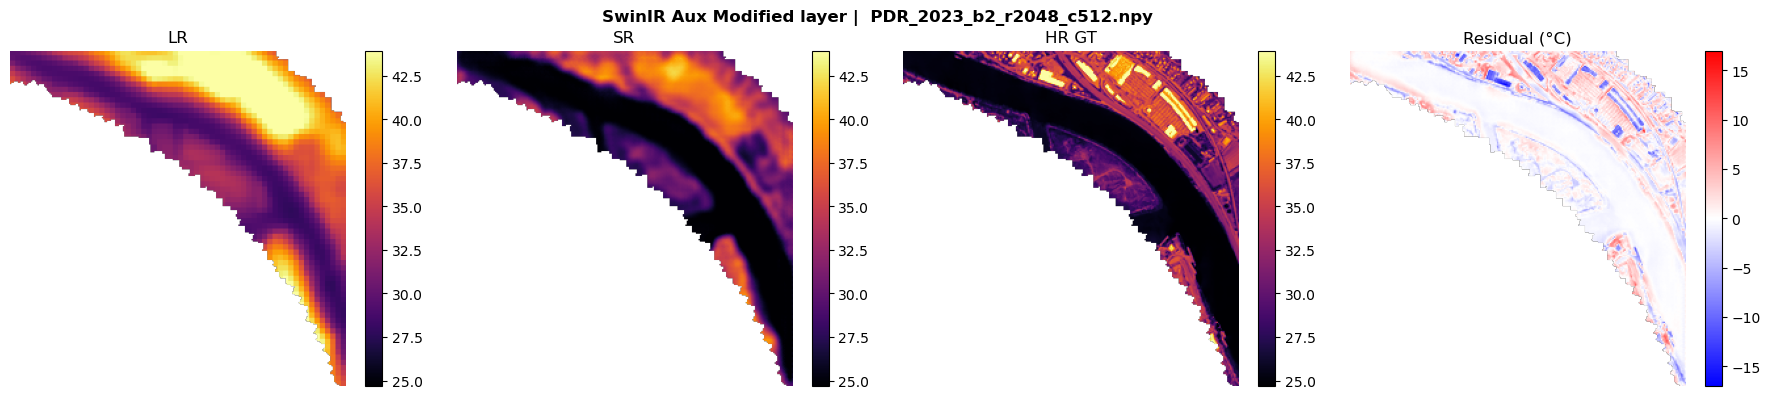

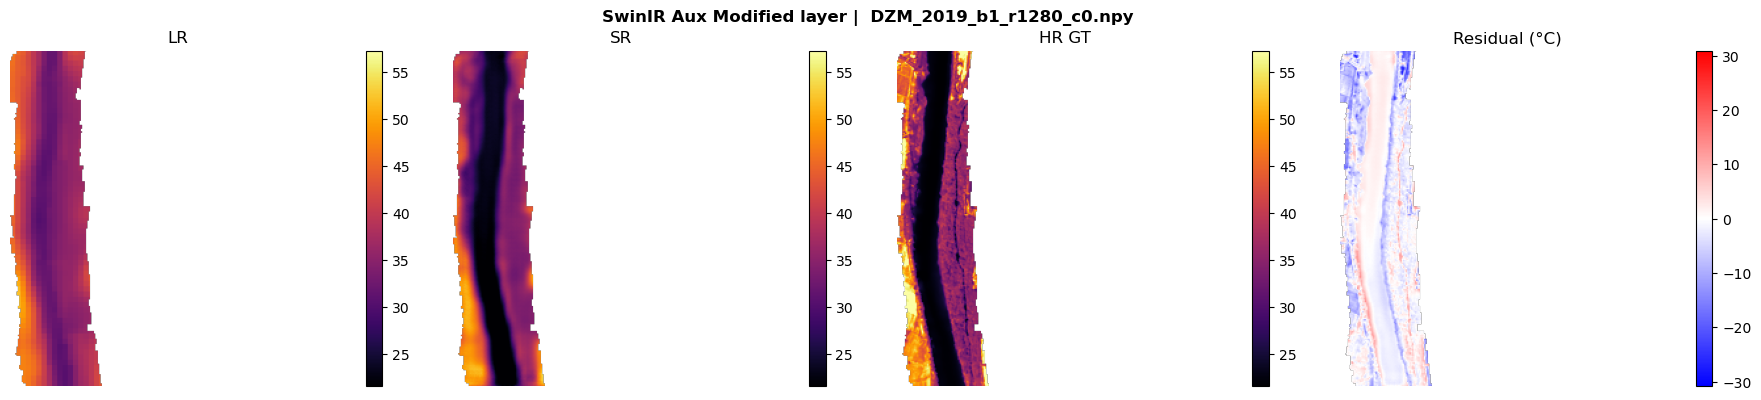

In [15]:
for sample in vis_samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux Modified layer |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual (°C)"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()


Running inference on full val set (36 samples)...


  36/36 done
Total valid pixels: 201,515


/tmp/ipykernel_3990742/1866954869.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scat.legend(fontsize=10, loc="upper left")


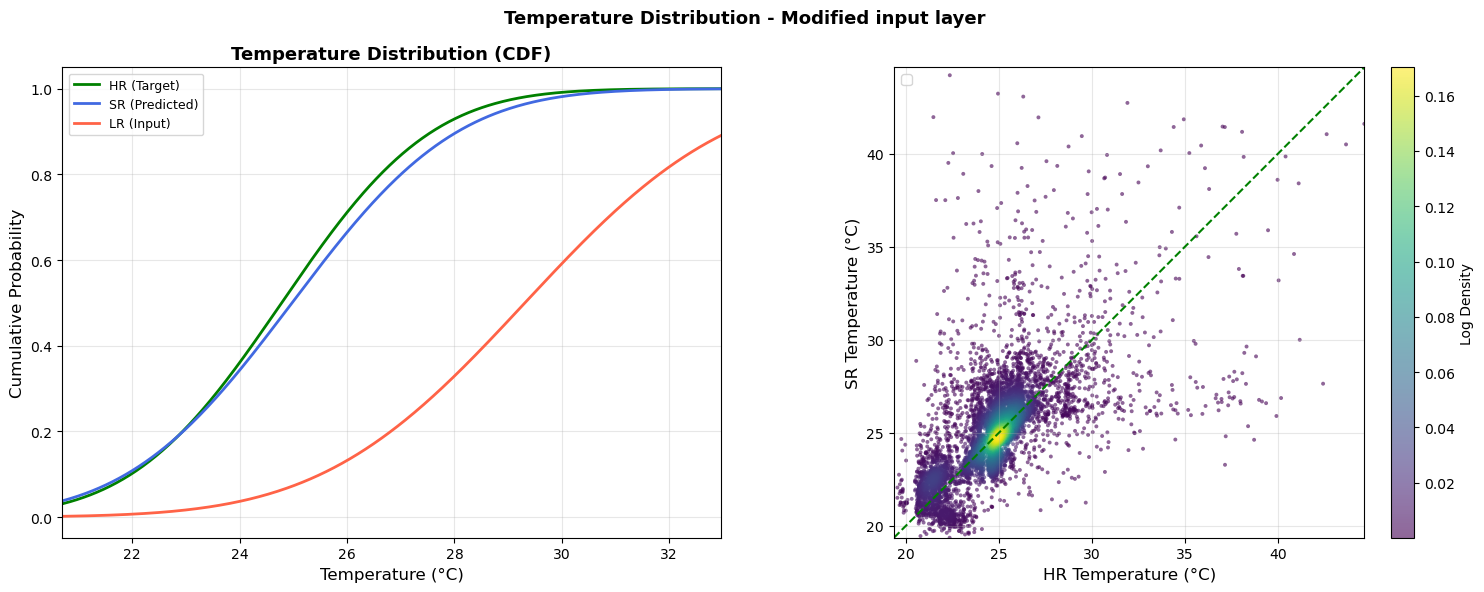

In [16]:
print(f"\nRunning inference on full val set ({len(val_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(val_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    water_mask = sample["water_mask"].squeeze().numpy()  # ← add this

    valid_mask = (hr_mask > 0.5) & (water_mask > 0.5)   # ← both conditions

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * LR_STD + LR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])
    # all_lr.append(lr_64)

    if (i + 1) % 50 == 0 or (i + 1) == len(val_ds):
        print(f"  {i + 1}/{len(val_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

vmin = np.percentile(hr_valid, 1)
vmax = np.percentile(hr_valid, 99)

palette = {"HR": "green",  "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid,     "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Temperature Distribution - Modified input layer",
             fontsize=13, fontweight="bold")

# CDF
ax_cdf = axes[0]
x      = np.linspace(vmin, vmax, 500) 

for key, vals in data.items():
    mu, std = stats.norm.fit(vals)
    ax_cdf.plot(
        x, stats.norm.cdf(x, mu, std),
        color=palette[key], lw=2,
        # label=f"{labels[key]} (μ={mu:.1f}°C, σ={std:.1f}°C)"
        label = f"{labels[key]}"
    )


ax_cdf.set_xlim(vmin, vmax)
ax_cdf.set_xlabel("Temperature (°C)", fontsize=12)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=12)
ax_cdf.set_title("Temperature Distribution (CDF)", fontsize=13, fontweight="bold")
ax_cdf.legend(fontsize=9, loc="upper left")
ax_cdf.grid(True, alpha=0.3)


# Scatter (subsample 10k points for speed)
ax_scat    = axes[1]
n_pts      = min(len(hr_valid), 10_000)
idx_sample = np.random.choice(len(hr_valid), n_pts, replace=False)
hr_s       = hr_valid[idx_sample]
sr_s       = sr_valid[idx_sample]

t_min = min(hr_s.min(), sr_s.min())
t_max = max(hr_s.max(), sr_s.max())

density     = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
log_density = np.log1p(density)
order       = log_density.argsort()

sc = ax_scat.scatter(
    hr_s[order], sr_s[order],
    c=log_density[order], cmap="viridis",
    s=8, alpha=0.6, linewidths=0
)
fig.colorbar(sc, ax=ax_scat, label="Log Density", fraction=0.046, pad=0.04)

ax_scat.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5)
ax_scat.set_xlim(t_min, t_max)
ax_scat.set_ylim(t_min, t_max)
ax_scat.set_aspect("equal")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=12)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=12)
ax_scat.legend(fontsize=10, loc="upper left")
ax_scat.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### fusion

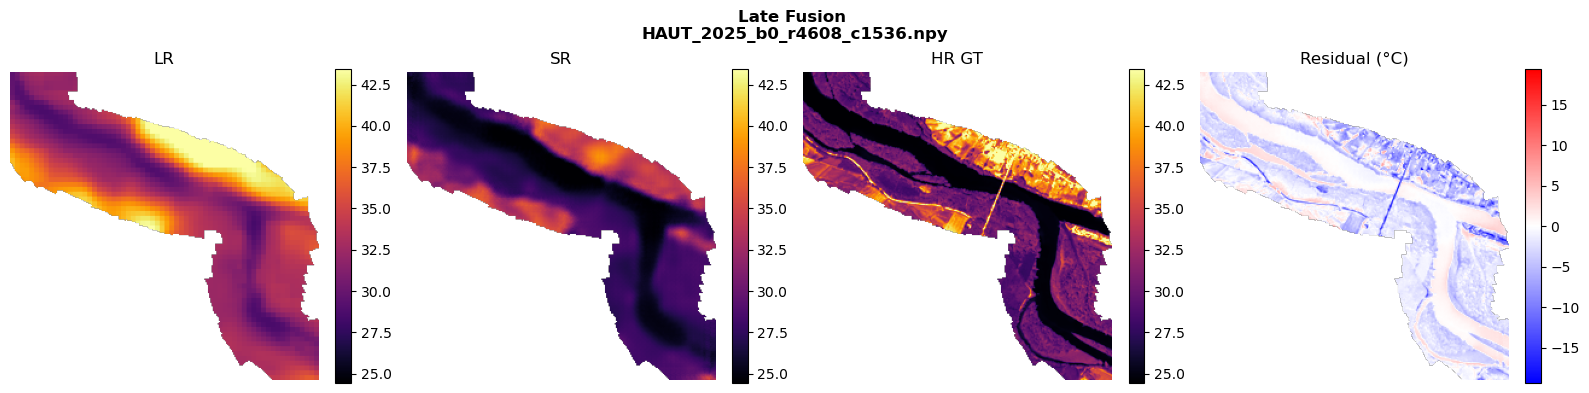

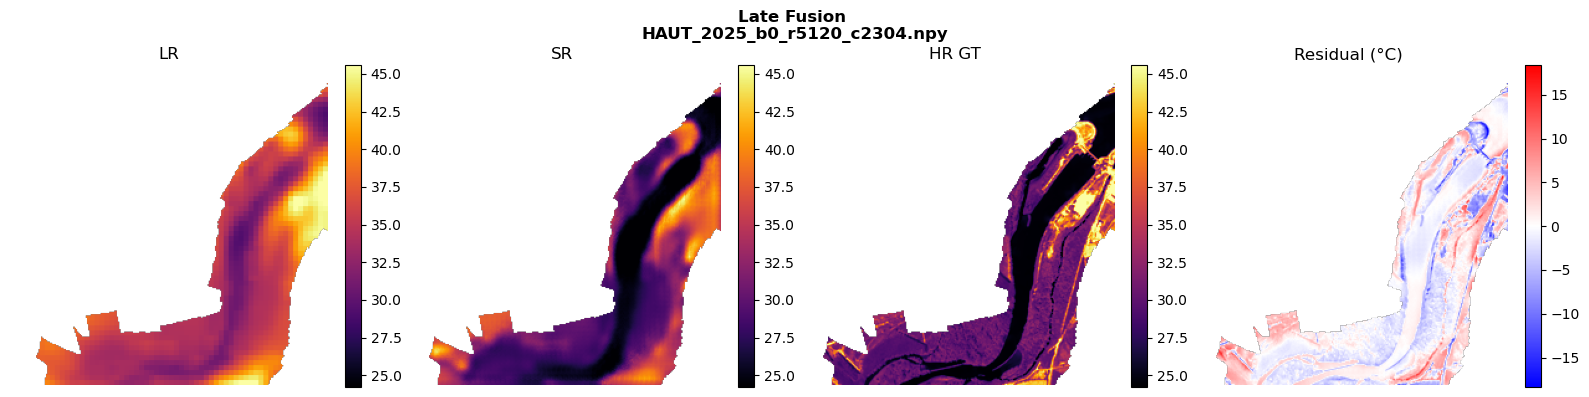

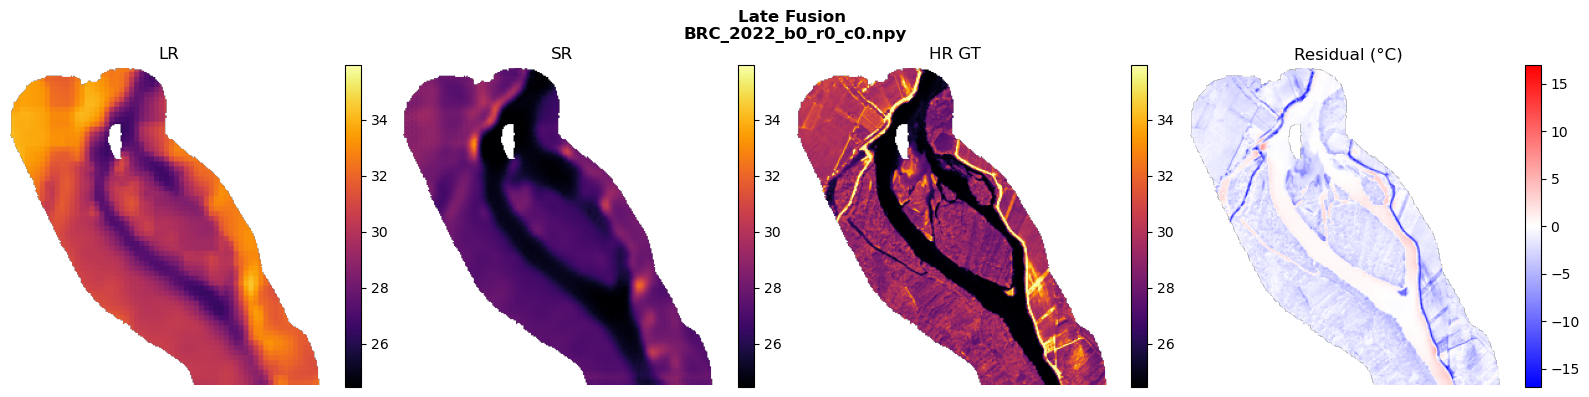

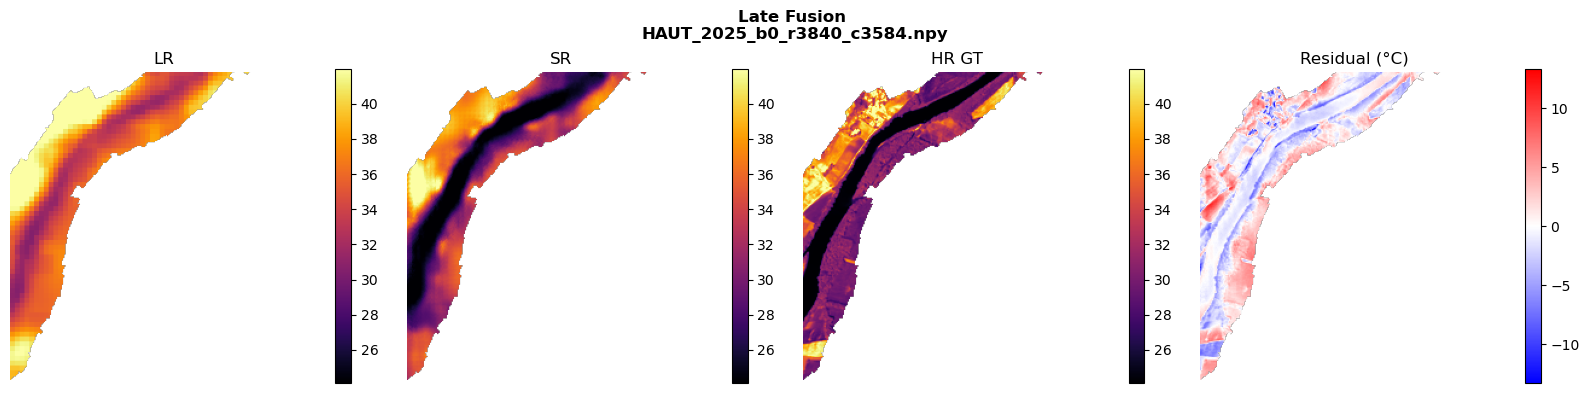

In [22]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Late Fusion \n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### loss vals

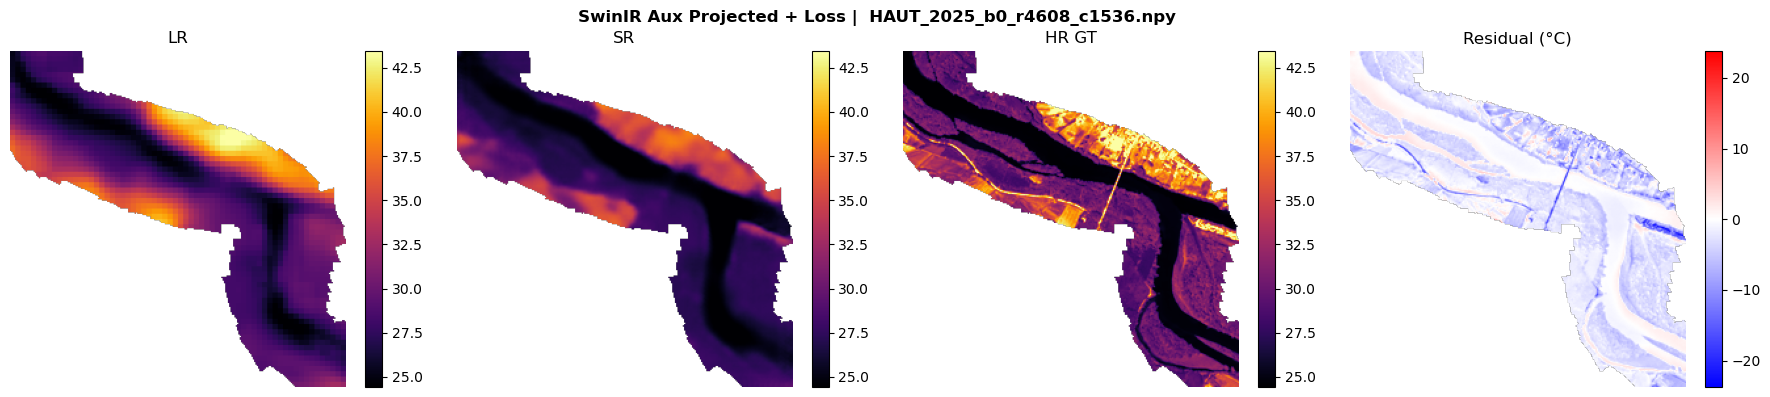

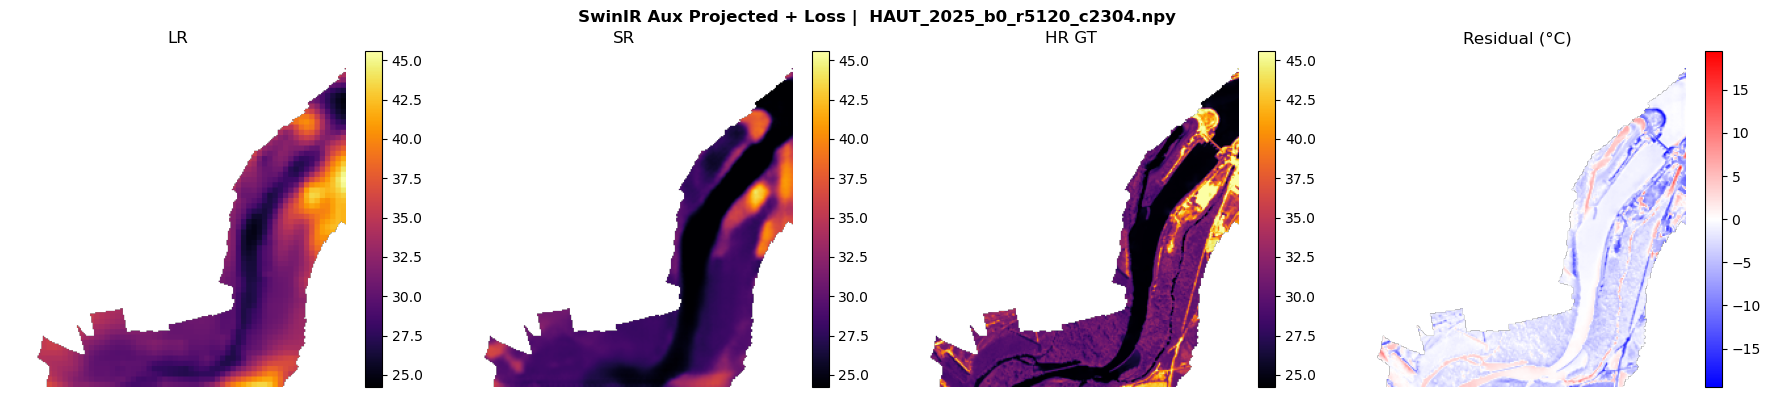

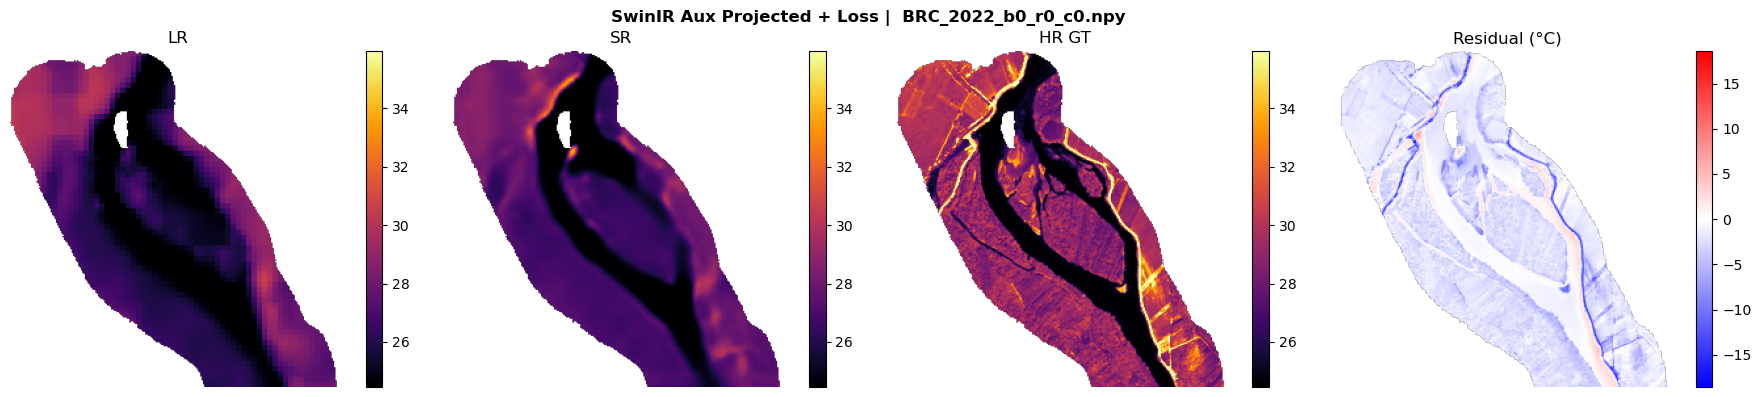

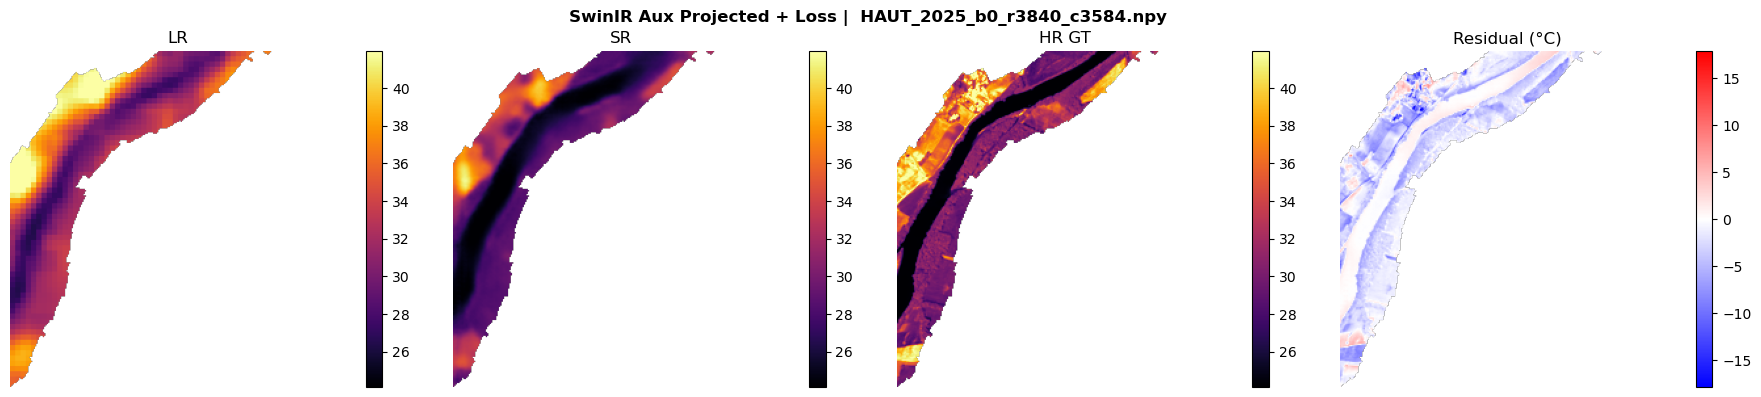

In [6]:
for sample in vis_samples:
    fname = sample["fname"]
    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)
    sr_celsius = run_inference(sample)
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    residual = sr_celsius - hr_np
    res_lim  = (np.nanmax(np.abs(residual)) if np.isfinite(residual).any() else 5)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f"SwinIR Aux Projected + Loss |  {fname}", fontsize=12, fontweight="bold")

    im = axes[0].imshow(lr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[0].set_title("LR"); axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    im = axes[1].imshow(sr_celsius, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[1].set_title("SR"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    im = axes[2].imshow(hr_np, cmap="inferno", vmin=vmin, vmax=vmax)
    axes[2].set_title("HR GT"); axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    im = axes[3].imshow(residual, cmap="bwr", vmin=-res_lim, vmax=res_lim)
    axes[3].set_title("Residual (°C)"); axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()
    torch.cuda.empty_cache()


Running inference on full test set (64 samples)...
  50/64 done
  64/64 done
Total valid pixels: 1,328,933


/tmp/ipykernel_290203/538325694.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_scat.legend(fontsize=10, loc="upper left")


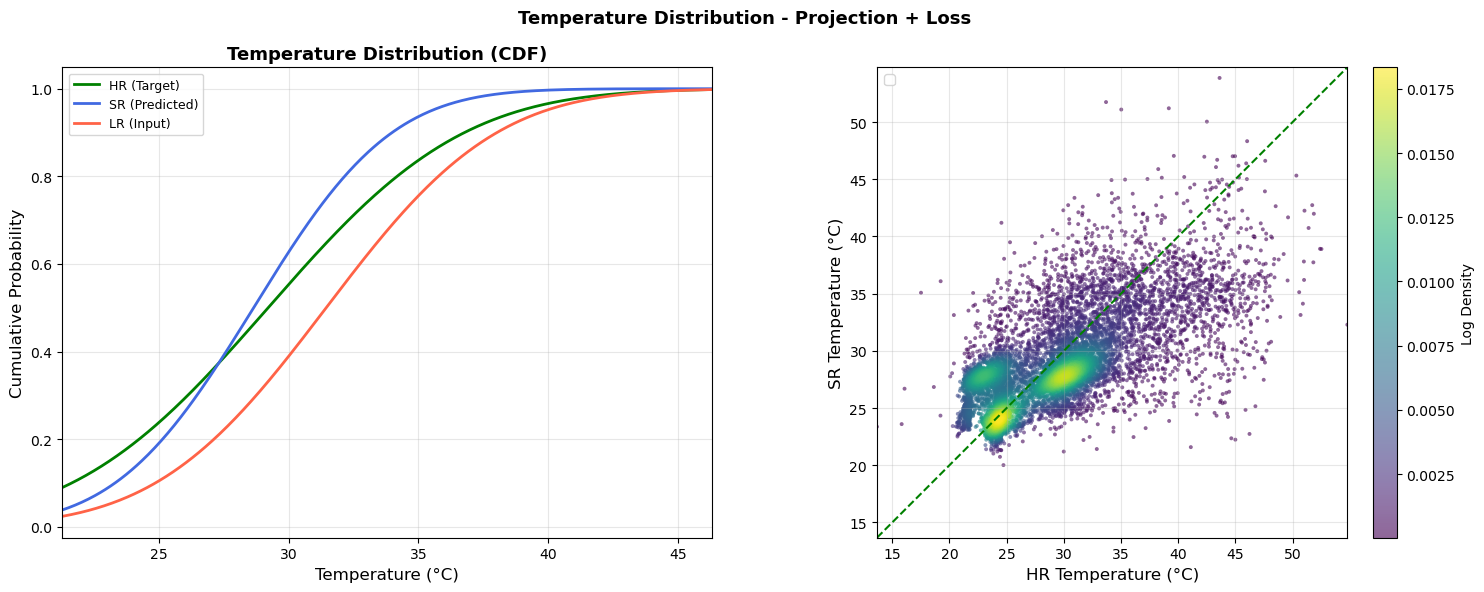

In [ ]:
print(f"\nRunning inference on full val set ({len(val_ds)} samples)...")

all_hr, all_sr, all_lr = [], [], []

for i, sample in enumerate(val_ds):
    hr_mask    = sample["hr_mask"].squeeze().numpy()
    valid_mask = hr_mask > 0.5

    if valid_mask.sum() == 0:
        continue

    lr_64  = sample["lr"][0].numpy() * HR_STD + HR_MEAN
    lr_256 = np.repeat(np.repeat(lr_64, 4, axis=0), 4, axis=1)
    hr_np  = sample["hr"][0].numpy() * HR_STD + HR_MEAN

    sr_celsius = run_inference(sample)

    all_hr.append(hr_np[valid_mask])
    all_sr.append(sr_celsius[valid_mask])
    all_lr.append(lr_256[valid_mask])
    # all_lr.append(lr_64)

    if (i + 1) % 50 == 0 or (i + 1) == len(val_ds):
        print(f"  {i + 1}/{len(val_ds)} done")

    torch.cuda.empty_cache()

hr_valid = np.concatenate(all_hr)
sr_valid = np.concatenate(all_sr)
lr_valid = np.concatenate(all_lr)
print(f"Total valid pixels: {len(hr_valid):,}")

vmin = np.percentile(hr_valid, 1)
vmax = np.percentile(hr_valid, 99)

palette = {"HR": "green",  "SR": "royalblue", "LR": "tomato"}
data    = {"HR": hr_valid, "SR": sr_valid,     "LR": lr_valid}
labels  = {"HR": "HR (Target)", "SR": "SR (Predicted)", "LR": "LR (Input)"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Temperature Distribution - Projection + Loss",
             fontsize=13, fontweight="bold")

# CDF
ax_cdf = axes[0]
x      = np.linspace(vmin, vmax, 500) 

for key, vals in data.items():
    mu, std = stats.norm.fit(vals)
    ax_cdf.plot(
        x, stats.norm.cdf(x, mu, std),
        color=palette[key], lw=2,
        # label=f"{labels[key]} (μ={mu:.1f}°C, σ={std:.1f}°C)"
        label = f"{labels[key]}"
    )


ax_cdf.set_xlim(vmin, vmax)
ax_cdf.set_xlabel("Temperature (°C)", fontsize=12)
ax_cdf.set_ylabel("Cumulative Probability", fontsize=12)
ax_cdf.set_title("Temperature Distribution (CDF)", fontsize=13, fontweight="bold")
ax_cdf.legend(fontsize=9, loc="upper left")
ax_cdf.grid(True, alpha=0.3)


# Scatter (subsample 10k points for speed)
ax_scat    = axes[1]
n_pts      = min(len(hr_valid), 10_000)
idx_sample = np.random.choice(len(hr_valid), n_pts, replace=False)
hr_s       = hr_valid[idx_sample]
sr_s       = sr_valid[idx_sample]

t_min = min(hr_s.min(), sr_s.min())
t_max = max(hr_s.max(), sr_s.max())

density     = gaussian_kde(np.vstack([hr_s, sr_s]))(np.vstack([hr_s, sr_s]))
log_density = np.log1p(density)
order       = log_density.argsort()

sc = ax_scat.scatter(
    hr_s[order], sr_s[order],
    c=log_density[order], cmap="viridis",
    s=8, alpha=0.6, linewidths=0
)
fig.colorbar(sc, ax=ax_scat, label="Log Density", fraction=0.046, pad=0.04)

ax_scat.plot([t_min, t_max], [t_min, t_max], "g--", lw=1.5)
ax_scat.set_xlim(t_min, t_max)
ax_scat.set_ylim(t_min, t_max)
ax_scat.set_aspect("equal")
ax_scat.set_xlabel("HR Temperature (°C)", fontsize=12)
ax_scat.set_ylabel("SR Temperature (°C)", fontsize=12)
ax_scat.legend(fontsize=10, loc="upper left")
ax_scat.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Late fusion

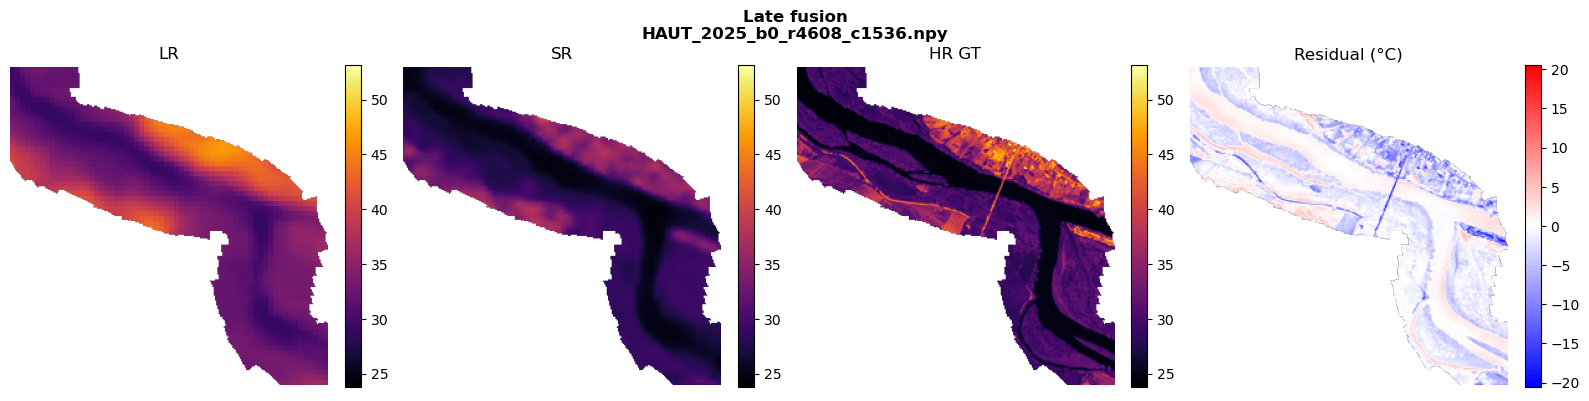

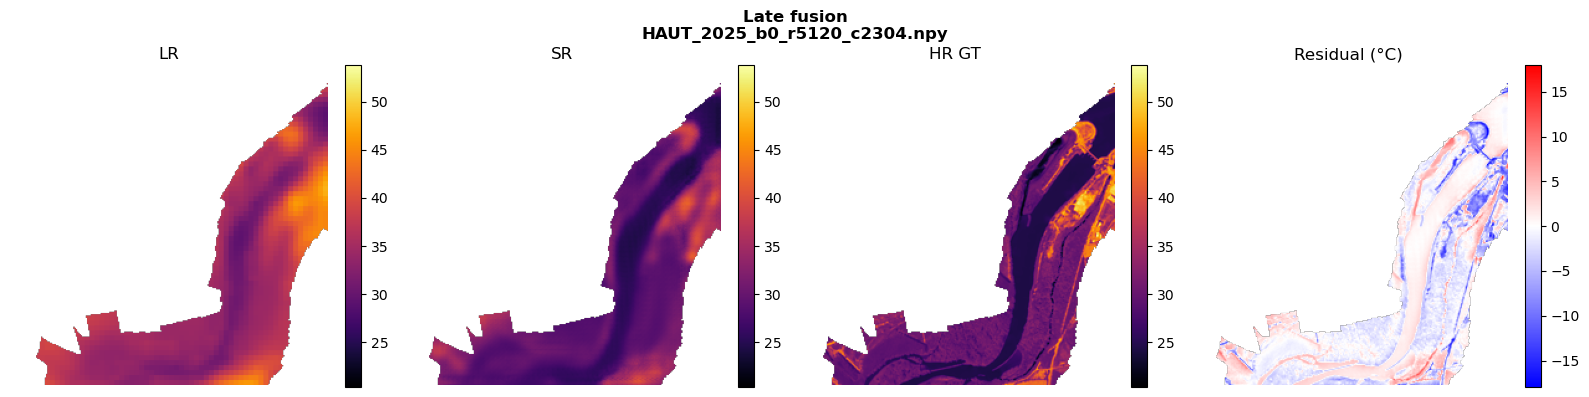

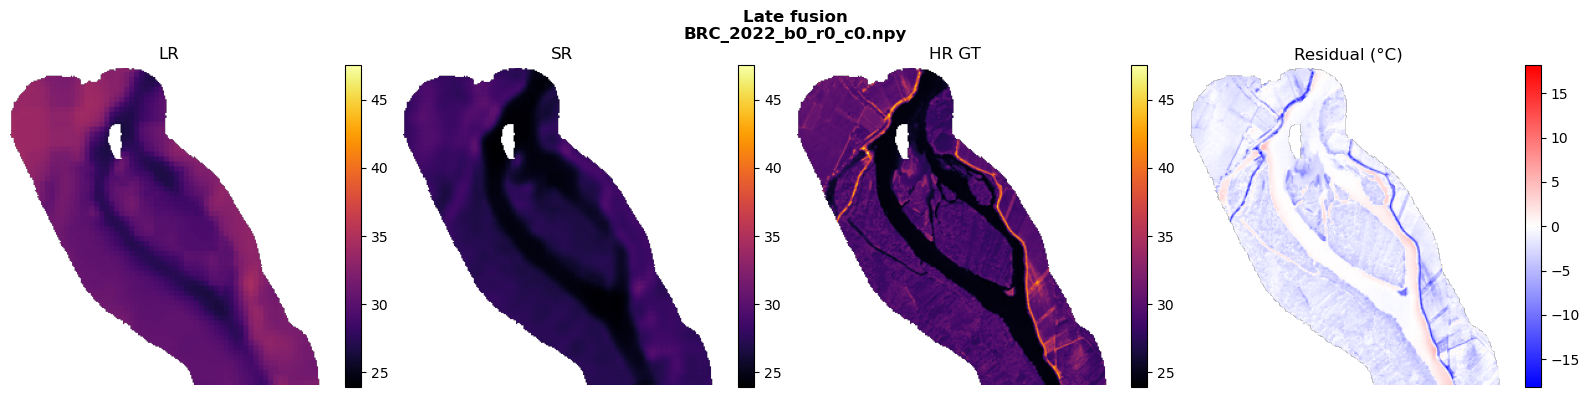

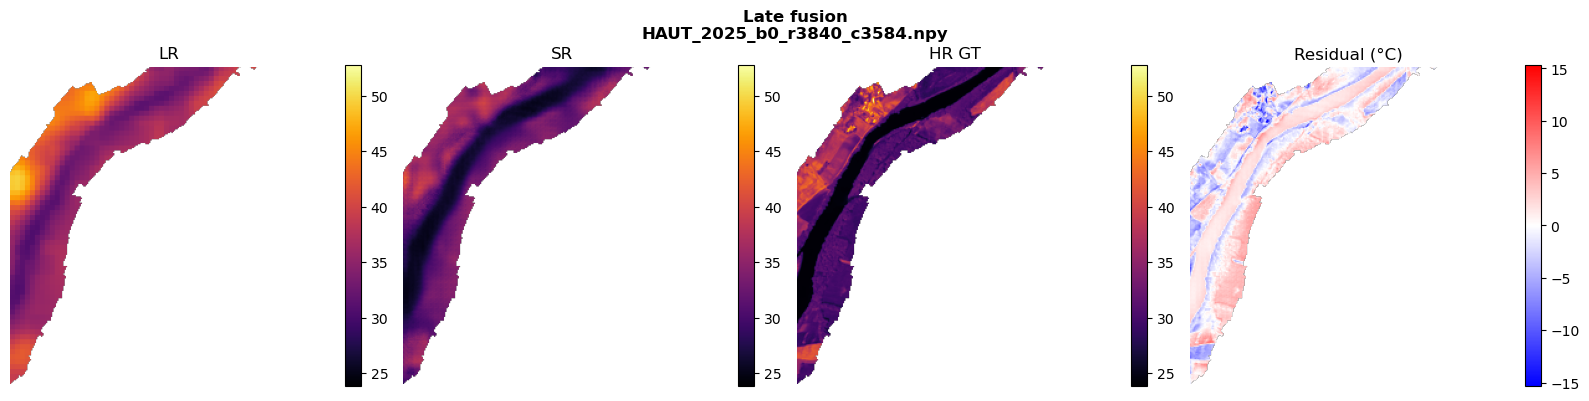

In [15]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Late fusion\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()

### Time conditioning

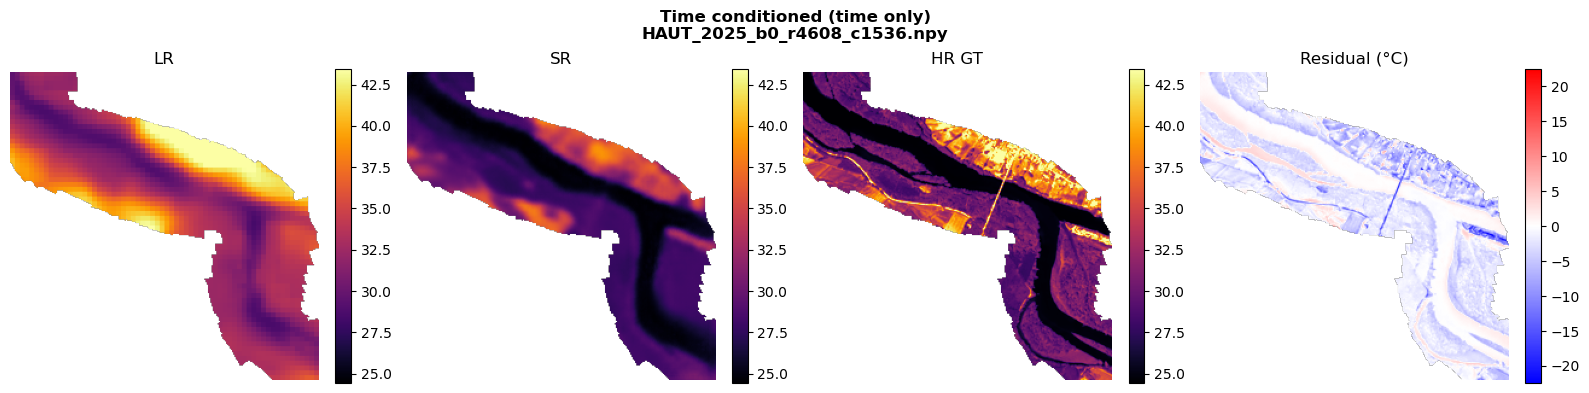

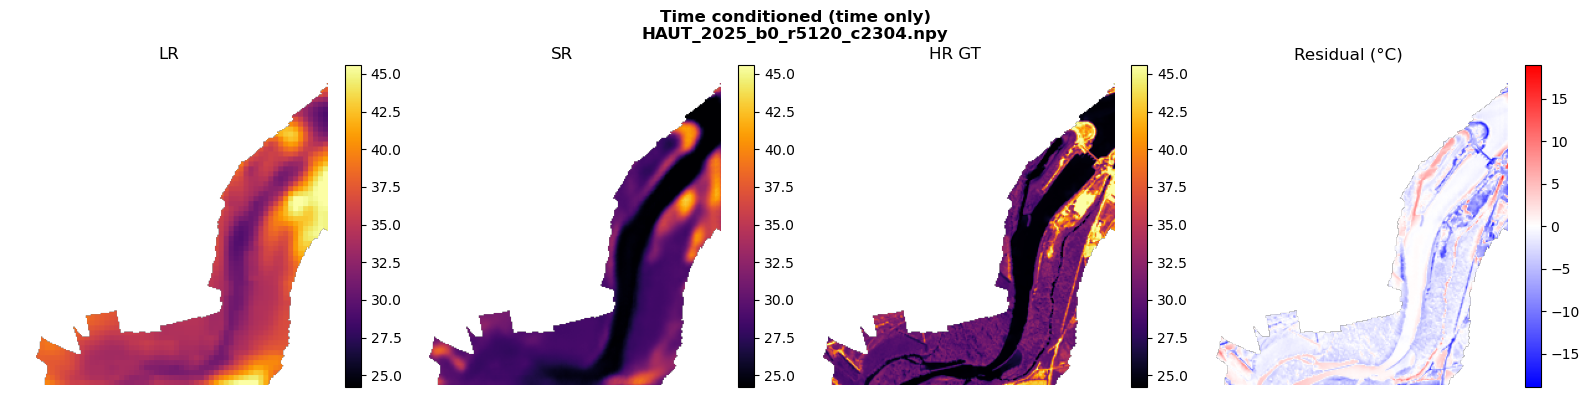

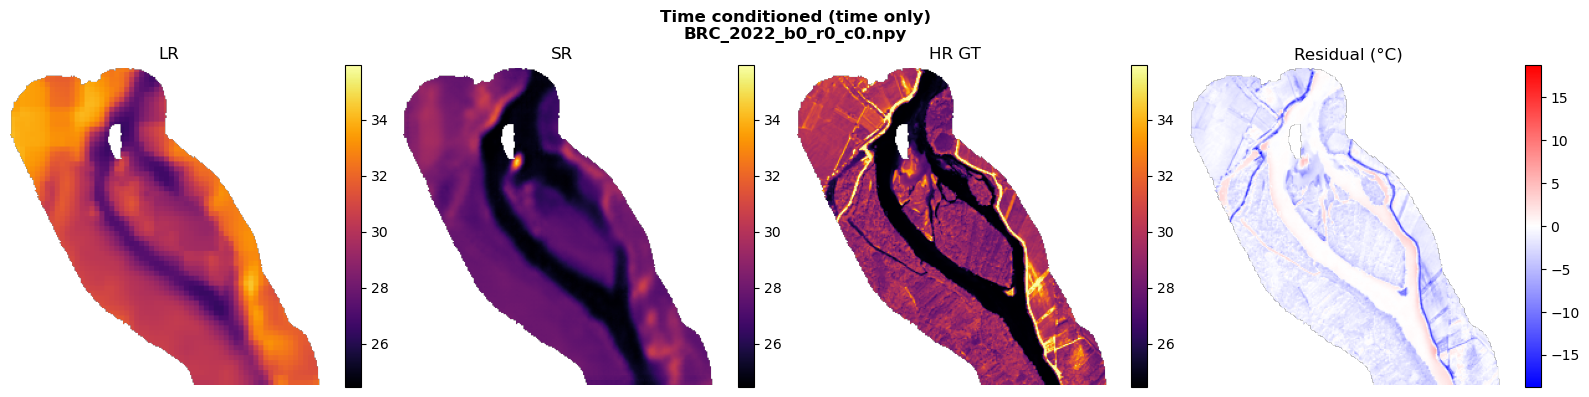

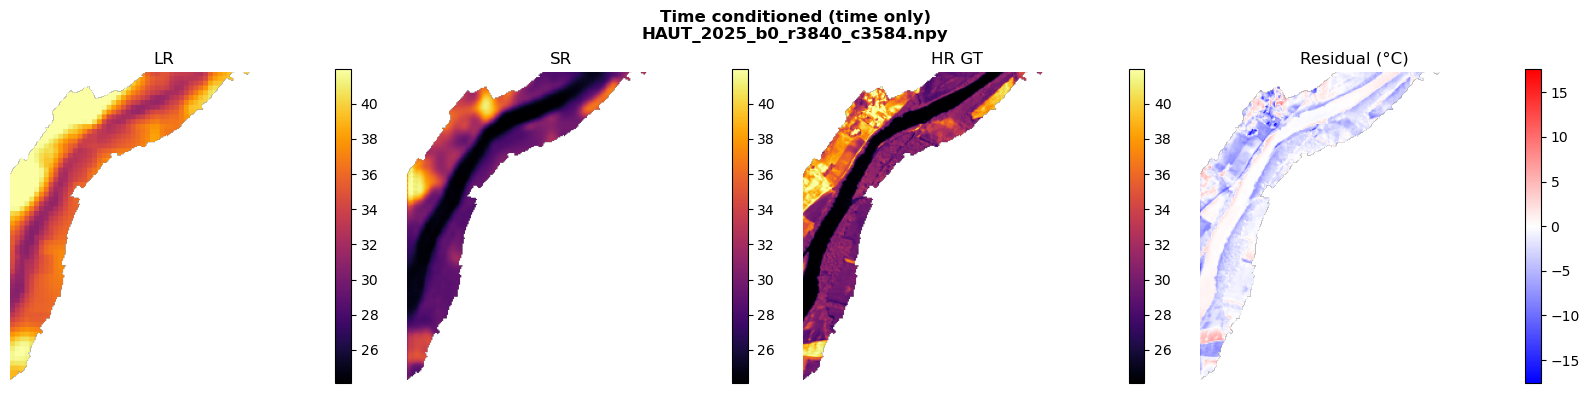

In [10]:
# Plot results
for s_idx, sample in enumerate(samples):

    fname = sample["fname"]

    lr_np, hr_np, hr_mask, vmin, vmax = prep_sample(sample)

    # Build batch for model
    batch = {"lr": sample["lr"].unsqueeze(0).to(device)}

    if "aux" in sample:
        batch["aux"] = sample["aux"].unsqueeze(0).to(device)

    # Inference
    with torch.no_grad():
        sr = model(batch)

    # Denormalize SR
    sr_celsius = (sr[:, 0:1] * HR_STD + HR_MEAN).squeeze().cpu().numpy()

    #mask invalid regions
    sr_celsius = np.where(hr_mask > 0.5, sr_celsius, np.nan)

    # Residual
    residual = sr_celsius - hr_np

    res_lim = (np.nanmax(np.abs(residual))if np.isfinite(residual).any()else 5)

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    fig.suptitle(f"Time conditioned (time only)\n{fname}",fontsize=12,fontweight="bold")

    # LR
    im = axes[0].imshow(lr_np,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[0].set_title("LR")
    axes[0].axis("off")
    plt.colorbar(im, ax=axes[0], fraction=0.046)

    # SR
    im = axes[1].imshow(sr_celsius,cmap="inferno",vmin=vmin,vmax=vmax)
    axes[1].set_title("SR")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    # HR
    im = axes[2].imshow( hr_np,cmap="inferno", vmin=vmin,vmax=vmax)
    axes[2].set_title("HR GT")
    axes[2].axis("off")
    plt.colorbar(im, ax=axes[2], fraction=0.046)

    # Residual
    im = axes[3].imshow(residual,cmap="bwr",vmin=-res_lim,vmax=res_lim)
    axes[3].set_title("Residual (°C)")
    axes[3].axis("off")
    plt.colorbar(im, ax=axes[3], fraction=0.046)

    plt.tight_layout()
    plt.show()

    torch.cuda.empty_cache()